# Synthetic blind ptychography on NVIDIA CUDA: 75% overlap, $\eta=0.2$

Runs on NVIDIA CUDA using the shared source modules. LSQML uses a Gaussian reconstruction likelihood; the simulated measurements use scaled-Poisson noise. 

Recorded run: `20260906T173714_962941Z`. All four methods completed 3,000 epochs. All original notebook outputs are preserved; no reconstruction or plot was rerun during cleanup. 

Set `SMOKE_TEST = True` for one epoch per method on the full synthetic dataset. Smoke archives use a separate `_smoke` directory. 

See [study details](../../README.md#experiments) and [noise.csv](../../results/noise.csv).


In [1]:
# ruff: noqa: E402 -- project path and environment must be configured first.
import os
from dataclasses import replace
from datetime import datetime, timezone
from pathlib import Path
import sys
import tempfile
from time import perf_counter

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "magpie-matplotlib"),
)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

PROJECT_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "src" / "utils" / "result_archive.py").is_file()
        and (candidate / "assets" / "baboon.tiff").is_file()
        and (candidate / "assets" / "cameraman.tif").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Open this notebook inside the repository with its src/ and assets/ directories."
    )
source_directory = str(PROJECT_ROOT / "src")
if source_directory in sys.path:
    sys.path.remove(source_directory)
sys.path.insert(0, source_directory)
for package_name in ("algorithms", "utils"):
    loaded = sys.modules.get(package_name)
    if loaded is not None and Path(loaded.__file__).resolve().parent != (
        PROJECT_ROOT / "src" / package_name
    ).resolve():
        raise RuntimeError(
            f"{package_name} was loaded from another project. "
            "Restart the kernel, then run this notebook from the top."
        )

import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb, to_rgb
import numpy as np
import ptychi.api as api
import torch

from algorithms.gm_rpie import run_gm_rpie
from algorithms.lsqml import LSQMLHyperparameters, run_lsqml
from algorithms.magpie import run_gm_magpie
from algorithms.rpie import run_rpie
from utils.common import configure_ptychi_device, cuda_runtime_preflight
from utils.reconstruction import make_frozen_amplitude_mse_evaluator
from utils.result_archive import save_synthetic_notebook_results
from utils.synthetic import (
    ExperimentConfig,
    build_synthetic_dataset,
    registered_object_truth_and_mask,
    score_blind_reconstruction,
)

## Shared settings

In [2]:
BASE_EXPERIMENT_NAME = "synthetic_overlap_075_eta_0p2"
SMOKE_TEST = False
PRODUCTION_NUM_EPOCHS = 3000
PRODUCTION_REPORT_EVERY = 20
NUM_EPOCHS = 1 if SMOKE_TEST else PRODUCTION_NUM_EPOCHS
REPORT_EVERY = 1 if SMOKE_TEST else PRODUCTION_REPORT_EVERY
EXPERIMENT_NAME = (
    f"{BASE_EXPERIMENT_NAME}_smoke" if SMOKE_TEST else BASE_EXPERIMENT_NAME
)
NOTEBOOK_PATH = PROJECT_ROOT / "examples" / "synthetic_noise" / f"{BASE_EXPERIMENT_NAME}.ipynb"
RESULTS_ROOT = PROJECT_ROOT / "results" / "notebook_exports" / "synthetic_noise" / EXPERIMENT_NAME
RUN_STARTED_UTC = datetime.now(timezone.utc)
RUN_ID = RUN_STARTED_UTC.strftime("%Y%m%dT%H%M%S_%fZ")

INCLUDE_INITIAL_METRICS = True
FROZEN_METRIC_EPS = 1e-7
RECONSTRUCTION_SEED = 21

BATCH_SIZE = 81
OBJECT_EXTRA_PIXELS = 10
OBJECT_STEP_SIZE = 1.0
PROBE_STEP_SIZE = 1.0
REMOVE_OBJECT_PROBE_AMBIGUITY = True
TRUTH_PROBE_DEFOCUS_M = -7e-4
INITIAL_PROBE_DEFOCUS_M = -5e-4

dataset_cfg = ExperimentConfig(
    overlap_ratio=0.75,
    position_jitter_px=4.0,
    position_seed=42,
    poisson_eta=0.2,
    detector_centered_data=True,
    data_seed=42,
    truth_probe_defocus_m=TRUTH_PROBE_DEFOCUS_M,
    initial_probe_defocus_m=INITIAL_PROBE_DEFOCUS_M,
)
shared_cfg = replace(
    dataset_cfg,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    object_extra_pixels=OBJECT_EXTRA_PIXELS,
    reconstruction_seed=RECONSTRUCTION_SEED,
    object_step_size=OBJECT_STEP_SIZE,
    probe_step_size=PROBE_STEP_SIZE,
    remove_object_probe_ambiguity=REMOVE_OBJECT_PROBE_AMBIGUITY,
)

METHOD_ORDER = ("rPIE", "LSQML", "GM-rPIE", "GM-MAGPIE")
METHOD_FILE_STEMS = {
    "rPIE": "rpie",
    "LSQML": "lsqml",
    "GM-rPIE": "gm_rpie",
    "GM-MAGPIE": "gm_magpie",
}
METHOD_COLORS = {
    "rPIE": "#55A868",
    "LSQML": "#4C72B0",
    "GM-rPIE": "#C44E52",
    "GM-MAGPIE": "#DD8452",
}

FROZEN_NOISY_KEY = "frozen_noisy_amplitude_mse"
FROZEN_NOISELESS_KEY = "frozen_noiseless_amplitude_mse"
FROZEN_METRIC_KEYS = (FROZEN_NOISY_KEY, FROZEN_NOISELESS_KEY)
TRUTH_METRIC_KEYS = (
    "phase_rmse_rad",
    "object_nmse",
    "object_magnitude_nrmse",
    "probe_nmse",
)
SAMPLED_METRIC_KEYS = (*TRUTH_METRIC_KEYS, *FROZEN_METRIC_KEYS)
METRIC_DEFINITIONS = {
    "online_preupdate_residual": (
        "Pty-Chi online loss evaluated from each minibatch prediction before "
        "that minibatch update; one aggregate value per epoch."
    ),
    FROZEN_NOISY_KEY: (
        "All-frame mean squared amplitude error against the fixed noisy "
        f"intensities, evaluated without updates using sqrt(I + {FROZEN_METRIC_EPS:g})."
    ),
    FROZEN_NOISELESS_KEY: (
        "All-frame mean squared amplitude error against the matching fixed "
        f"noiseless intensities, evaluated without updates using sqrt(I + {FROZEN_METRIC_EPS:g})."
    ),
    "phase_rmse_rad": (
        "Truth-weighted object phase RMSE in radians on the registered "
        "illuminated support after blind-gauge alignment."
    ),
    "object_nmse": (
        "Complex object NMSE on the registered illuminated support after "
        "blind-gauge alignment."
    ),
    "object_magnitude_nrmse": (
        "Object-magnitude normalized RMSE on the registered illuminated support."
    ),
    "probe_nmse": (
        "Complex probe NMSE after applying the object-derived reciprocal "
        "blind gauge and removing the remaining global exit-wave phase."
    ),
}

if NUM_EPOCHS < 1 or REPORT_EVERY < 1:
    raise ValueError("NUM_EPOCHS and REPORT_EVERY must be positive.")

results = {}
runtimes_seconds = {}
method_run_parameters = {}
if SMOKE_TEST:
    print("SMOKE TEST: one epoch per method on the full synthetic dataset.")


## Helpers

In [3]:
def blend_with_white(color, white_fraction=0.55):
    rgb = np.asarray(to_rgb(color), dtype=np.float64)
    return tuple((1.0 - white_fraction) * rgb + white_fraction)


PANEL_FRAME_COLORS = {
    "Truth": "#BDBDBD",
    **{
        method: blend_with_white(color)
        for method, color in METHOD_COLORS.items()
    },
}


def robust_limits(values, percentiles, *, nonnegative=False):
    finite = np.asarray(values)[np.isfinite(values)]
    if finite.size == 0:
        return 0.0, 1.0
    low, high = (float(value) for value in np.percentile(finite, percentiles))
    if nonnegative:
        low = max(0.0, low)
    if high <= low:
        high = low + max(1e-6, 1e-3 * max(abs(low), 1.0))
    return low, high


def complex_to_rgb(field, magnitude_max, *, gamma=0.6):
    field = np.asarray(field).squeeze()
    if field.ndim != 2:
        raise ValueError(f"Expected a 2D complex field, got {field.shape}.")
    magnitude = np.abs(field)
    phase = np.angle(field)
    finite = np.isfinite(magnitude) & np.isfinite(phase)
    hue = np.mod((phase + np.pi) / (2.0 * np.pi), 1.0)
    value = np.zeros_like(magnitude, dtype=np.float32)
    value[finite] = np.clip(magnitude[finite] / magnitude_max, 0.0, 1.0) ** gamma
    rgb = hsv_to_rgb(np.stack((hue, np.ones_like(hue), value), axis=-1))
    rgb[~finite] = 0.0
    return np.asarray(rgb, dtype=np.float32)


def valid_dyadic_levels(height, width):
    levels = 1
    while height % 2 == 0 and width % 2 == 0 and min(height, width) >= 2:
        height //= 2
        width //= 2
        levels += 1
    return levels


def make_progress_callback(method_name):
    def report(epoch, _online_residual, metrics):
        residual = metrics[FROZEN_NOISY_KEY]
        print(
            f"\r{method_name}: epoch {epoch}/{NUM_EPOCHS}, "
            f"frozen MSE={residual:.3e}",
            end="",
            flush=True,
        )

    return report


def reconstruction_kwargs(method_name):
    return {
        "seed": RECONSTRUCTION_SEED,
        "error_stride": REPORT_EVERY,
        "include_initial_metrics": INCLUDE_INITIAL_METRICS,
        "progress_callback": make_progress_callback(method_name),
        "task_metric_function": frozen_checkpoint_evaluator,
        "final_metric_function": frozen_checkpoint_evaluator,
    }


def validate_result(method_name, result):
    expected_epochs = np.asarray(
        sorted(
            {
                0,
                1,
                NUM_EPOCHS,
                *range(REPORT_EVERY, NUM_EPOCHS + 1, REPORT_EVERY),
            }
        ),
        dtype=np.int64,
    )
    if result.residual_history.shape != (NUM_EPOCHS,):
        raise ValueError(f"{method_name}: unexpected residual-history shape.")
    if not np.all(np.isfinite(result.residual_history)):
        raise ValueError(f"{method_name}: residual history is not finite.")
    np.testing.assert_array_equal(result.metric_epochs, expected_epochs)
    if set(result.metric_history) != set(SAMPLED_METRIC_KEYS):
        raise ValueError(f"{method_name}: unexpected metric names.")
    for metric_name, values in result.metric_history.items():
        if values.shape != expected_epochs.shape or not np.all(
            np.isfinite(values)
        ):
            raise ValueError(f"{method_name}: invalid {metric_name} history.")
    if set(result.final_metrics) != set(FROZEN_METRIC_KEYS):
        raise ValueError(f"{method_name}: unexpected final metrics.")
    if not np.all(np.isfinite(result.object)):
        raise ValueError(f"{method_name}: object contains nonfinite values.")
    if not np.all(np.isfinite(result.probe)):
        raise ValueError(f"{method_name}: probe contains nonfinite values.")

def store_result(method_name, result, runtime_seconds, parameters):
    validate_result(method_name, result)
    runtime_seconds = float(runtime_seconds)
    if not np.isfinite(runtime_seconds) or runtime_seconds <= 0:
        raise ValueError(f"{method_name}: runtime must be finite and positive.")
    results[method_name] = result
    runtimes_seconds[method_name] = runtime_seconds
    method_run_parameters[method_name] = dict(parameters)
    for mapping_name in ("scores", "aligned_objects", "aligned_probes"):
        mapping = globals().get(mapping_name)
        if isinstance(mapping, dict):
            mapping.pop(method_name, None)
    print(f"\n{method_name} finished in {runtime_seconds / 60.0:.2f} min")


def completed_methods():
    methods = [method for method in METHOD_ORDER if method in results]
    if not methods:
        raise RuntimeError("Run at least one method cell first.")
    missing = [method for method in METHOD_ORDER if method not in results]
    if missing:
        print("Not run: " + ", ".join(missing))
    return methods

## Data

In [4]:
device = configure_ptychi_device()
DEVICE_INFO = cuda_runtime_preflight()
print(
    f"torch={DEVICE_INFO['torch_version']}, "
    f"CUDA={DEVICE_INFO['torch_cuda_version']}, "
    f"GPU={DEVICE_INFO['gpu_name']}, "
    f"capability={tuple(DEVICE_INFO['compute_capability'])}"
)
print(f"mode={'SMOKE' if SMOKE_TEST else 'PRODUCTION'}, project={PROJECT_ROOT}")
dataset = build_synthetic_dataset(dataset_cfg)
noiseless_dataset = build_synthetic_dataset(
    replace(dataset_cfg, poisson_eta=0.0)
)
frozen_checkpoint_evaluator = make_frozen_amplitude_mse_evaluator(
    {
        FROZEN_NOISY_KEY: dataset.data,
        FROZEN_NOISELESS_KEY: noiseless_dataset.data,
    },
    batch_size=BATCH_SIZE,
    eps=FROZEN_METRIC_EPS,
)

results.clear()
runtimes_seconds.clear()
method_run_parameters.clear()
for stale_name in (
    "scores",
    "aligned_objects",
    "aligned_probes",
    "registered_truth",
    "illuminated",
):
    globals().pop(stale_name, None)

print(f"device={device.value}, patterns={len(dataset.data)}")

torch=2.11.0+cu130, CUDA=13.0, GPU=NVIDIA RTX PRO 6000 Blackwell Server Edition, capability=(12, 0)
mode=PRODUCTION, project=<original-project>
device=gpu, patterns=729


The object/probe alphas are (0.1, 0.1) for rPIE, (0.01, 0.01) for GM-rPIE, and (0.05, 0.01) for GM-MAGPIE. LSQML uses Gaussian sigma=0.5 and object/probe optimal-step multipliers 0.9/0.9, with outer SGD step sizes 1.0/1.0. These values are explicit in the method cells and match the recorded run. All methods share the initialization, scan positions, batch size, seeds, and epoch budget.

## rPIE

In [5]:
RPIE_ALPHAS = (0.1, 0.1)

rpie_cfg = replace(
    shared_cfg,
    object_alpha=RPIE_ALPHAS[0],
    probe_alpha=RPIE_ALPHAS[1],
)
torch.cuda.synchronize()
started = perf_counter()
rpie_result = run_rpie(
    dataset,
    rpie_cfg,
    device,
    **reconstruction_kwargs("rPIE"),
)
torch.cuda.synchronize()
store_result(
    "rPIE",
    rpie_result,
    perf_counter() - started,
    {"runner": "run_rpie", "config": rpie_cfg},
)

rPIE: epoch 3000/3000, frozen MSE=8.121e-02
rPIE finished in 3.74 min


## LSQML — Gaussian likelihood


In [6]:
# Archived LSQML hyperparameters, explicit here: Gaussian sigma=0.5 and
# optimal-step multipliers 0.9/0.9. These multipliers are separate from
# the explicitly unit outer object/probe SGD step sizes below.
lsqml_cfg = replace(
    shared_cfg,
    object_step_size=1.0,
    probe_step_size=1.0,
)
lsqml_hyperparameters = LSQMLHyperparameters(
    noise_model=api.NoiseModels.GAUSSIAN,
    gaussian_noise_std=0.5,
    object_step_size_scaler=0.9,
    probe_step_size_scaler=0.9,
)
print("LSQML configuration:", lsqml_cfg)
print("LSQML hyperparameters:", lsqml_hyperparameters)

torch.cuda.synchronize()
started = perf_counter()
lsqml_result = run_lsqml(
    dataset,
    lsqml_cfg,
    device,
    hyperparameters=lsqml_hyperparameters,
    **reconstruction_kwargs("LSQML"),
)
torch.cuda.synchronize()
store_result(
    "LSQML",
    lsqml_result,
    perf_counter() - started,
    {
        "runner": "run_lsqml",
        "config": lsqml_cfg,
        "hyperparameters": lsqml_hyperparameters,
    },
)


LSQML configuration: ExperimentConfig(asset_dir=PosixPath('<original-project>/assets'), object_size=1024, probe_size=128, overlap_ratio=0.75, position_jitter_px=4.0, position_seed=42, poisson_eta=0.2, detector_centered_data=True, data_seed=42, probe_source_size=512, wavelength_m=1e-10, sample_pixel_size_m=1e-08, total_probe_power=300.0, truth_probe_defocus_m=-0.0007, initial_probe_defocus_m=-0.0005, reconstruction_seed=21, num_epochs=3000, batch_size=81, object_extra_pixels=10, object_alpha=0.01, object_step_size=1.0, probe_alpha=0.3, probe_step_size=1.0, remove_object_probe_ambiguity=True)
LSQML hyperparameters: LSQMLHyperparameters(object_step_size_scaler=0.9, probe_step_size_scaler=0.9, gaussian_noise_std=0.5, noise_model=<NoiseModels.GAUSSIAN: 'gaussian'>)
LSQML: epoch 3000/3000, frozen MSE=8.040e-02
LSQML finished in 5.18 min


## GM-rPIE

In [7]:
GM_RPIE_ALPHAS = (0.01, 0.01)

gm_rpie_cfg = replace(
    shared_cfg,
    object_alpha=GM_RPIE_ALPHAS[0],
    probe_alpha=GM_RPIE_ALPHAS[1],
)
torch.cuda.synchronize()
started = perf_counter()
gm_rpie_result = run_gm_rpie(
    dataset,
    gm_rpie_cfg,
    device,
    **reconstruction_kwargs("GM-rPIE"),
)
torch.cuda.synchronize()
store_result(
    "GM-rPIE",
    gm_rpie_result,
    perf_counter() - started,
    {
        "runner": "run_gm_rpie",
        "config": gm_rpie_cfg,
        "effective_multigrid_levels": 1,
    },
)

GM-rPIE: epoch 3000/3000, frozen MSE=9.644e-02
GM-rPIE finished in 4.49 min


## GM-MAGPIE

In [8]:
GM_MAGPIE_ALPHAS = (0.05, 0.01)

gm_magpie_cfg = replace(
    shared_cfg,
    object_alpha=GM_MAGPIE_ALPHAS[0],
    probe_alpha=GM_MAGPIE_ALPHAS[1],
)
torch.cuda.synchronize()
started = perf_counter()
gm_magpie_result = run_gm_magpie(
    dataset,
    gm_magpie_cfg,
    device,
    **reconstruction_kwargs("GM-MAGPIE"),
)
torch.cuda.synchronize()
store_result(
    "GM-MAGPIE",
    gm_magpie_result,
    perf_counter() - started,
    {
        "runner": "run_gm_magpie",
        "config": gm_magpie_cfg,
        "requested_multigrid_levels": None,
        "effective_multigrid_levels": valid_dyadic_levels(
            *dataset.probe_init.shape[-2:]
        ),
    },
)

GM-MAGPIE: epoch 3000/3000, frozen MSE=5.530e-02
GM-MAGPIE finished in 6.11 min


## Scores

In [9]:
methods = completed_methods()
scores = {}
aligned_objects = {}
aligned_probes = {}
registered_truth = None
illuminated = None

for method_name in methods:
    result = results[method_name]
    metrics, object_aligned, probe_aligned = score_blind_reconstruction(
        result.object,
        result.probe,
        dataset,
    )
    scores[method_name] = metrics
    aligned_objects[method_name] = object_aligned
    aligned_probes[method_name] = probe_aligned

    method_truth, method_mask = registered_object_truth_and_mask(
        result.object,
        dataset,
    )
    if registered_truth is None:
        registered_truth = method_truth
        illuminated = method_mask
    else:
        np.testing.assert_array_equal(method_truth, registered_truth)
        np.testing.assert_array_equal(method_mask, illuminated)

print(
    f"{'method':<12} {'frozen MSE':>14} {'phase RMSE':>14} "
    f"{'object NMSE':>14} {'probe NMSE':>14}"
)
print("-" * 72)
for method_name in methods:
    result = results[method_name]
    print(
        f"{method_name:<12} "
        f"{result.final_metrics[FROZEN_NOISY_KEY]:>14.3e} "
        f"{scores[method_name]['phase_rmse_rad']:>14.3e} "
        f"{scores[method_name]['object_nmse']:>14.3e} "
        f"{scores[method_name]['probe_nmse']:>14.3e}"
    )

method           frozen MSE     phase RMSE    object NMSE     probe NMSE
------------------------------------------------------------------------
rPIE              8.121e-02      1.514e-01      3.771e-02      1.118e+00
LSQML             8.040e-02      1.636e-01      4.440e-02      1.371e+00
GM-rPIE           9.644e-02      1.543e-01      3.107e-02      1.042e-03
GM-MAGPIE         5.530e-02      1.016e-01      1.559e-02      3.487e-04


## Save numeric notebook-run archive

After **Restart Kernel and Run All Cells**, the next cell saves a complete numeric archive under `results/notebook_exports/synthetic_noise/synthetic_overlap_075_eta_0p2/`. Each run has a new immutable directory containing raw and aligned complex reconstructions, noisy/noiseless inputs, truth arrays, all metrics and residuals, method settings, runtimes, source hashes, and checksums. Rendered figures can be regenerated from the saved arrays.

In [10]:
source_paths = {
    str(path.relative_to(PROJECT_ROOT)): path
    for path in sorted((PROJECT_ROOT / "src").rglob("*.py"))
}
for relative_path in (
    "pyproject.toml",
    "assets/baboon.tiff",
    "assets/cameraman.tif",
):
    source_paths[relative_path] = PROJECT_ROOT / relative_path

saved_run_dir = save_synthetic_notebook_results(
    output_root=RESULTS_ROOT,
    project_root=PROJECT_ROOT,
    experiment_name=EXPERIMENT_NAME,
    notebook_path=NOTEBOOK_PATH,
    run_started_utc=RUN_STARTED_UTC,
    run_id=RUN_ID,
    dataset_config=dataset_cfg,
    shared_config=shared_cfg,
    method_order=METHOD_ORDER,
    method_file_stems=METHOD_FILE_STEMS,
    method_parameters=method_run_parameters,
    results=results,
    runtimes_seconds=runtimes_seconds,
    scores=scores,
    aligned_objects=aligned_objects,
    aligned_probes=aligned_probes,
    registered_truth=registered_truth,
    illuminated=illuminated,
    dataset=dataset,
    noiseless_dataset=noiseless_dataset,
    metric_report_every=REPORT_EVERY,
    include_initial_metrics=INCLUDE_INITIAL_METRICS,
    frozen_metric_eps=FROZEN_METRIC_EPS,
    sampled_metric_keys=SAMPLED_METRIC_KEYS,
    final_metric_keys=FROZEN_METRIC_KEYS,
    truth_metric_keys=TRUTH_METRIC_KEYS,
    device=device,
    source_paths=source_paths,
    metric_definitions=METRIC_DEFINITIONS,
    run_metadata={
        "smoke_test": SMOKE_TEST,
        "base_experiment_name": BASE_EXPERIMENT_NAME,
        "production_num_epochs": PRODUCTION_NUM_EPOCHS,
        "effective_num_epochs": NUM_EPOCHS,
        "cuda_preflight": DEVICE_INFO,
    },
    timing_notes=(
        f"Each method runtime spans task construction, {NUM_EPOCHS:,} "
        "reconstruction epochs, and sampled frozen/truth metrics. "
        "CUDA is synchronized immediately before and after each timed run; "
        "preflight and dataset construction are outside that interval."
    ),
)
print(f"Saved and verified complete run: {saved_run_dir}")

Saved and verified complete run: <original-project>/results/notebook_exports/synthetic_overlap_075_eta_0p2/20260906T173714_962941Z


Load an archived reconstruction without pickle, for example:

```python
with np.load(saved_run_dir / "reconstructions" / "gm_magpie.npz", allow_pickle=False) as saved:
    gm_magpie_object_raw = saved["object"]
    gm_magpie_probe_raw = saved["probe"]
    gm_magpie_object_aligned = saved["aligned_object"]
    gm_magpie_probe_aligned = saved["aligned_probe"]
```

These are complex-valued pixel arrays; use `np.abs(...)` and `np.angle(...)` when you are ready to design new figures. The authoritative scalar and curve sources are `tables/summary.csv`, `curves/metric_history.csv`, and `curves/residual_history.csv`. Because generated `results/notebook_exports/` archives are Git-ignored, copy the completed directory to durable storage when it is ready for paper use.

## Metric curves

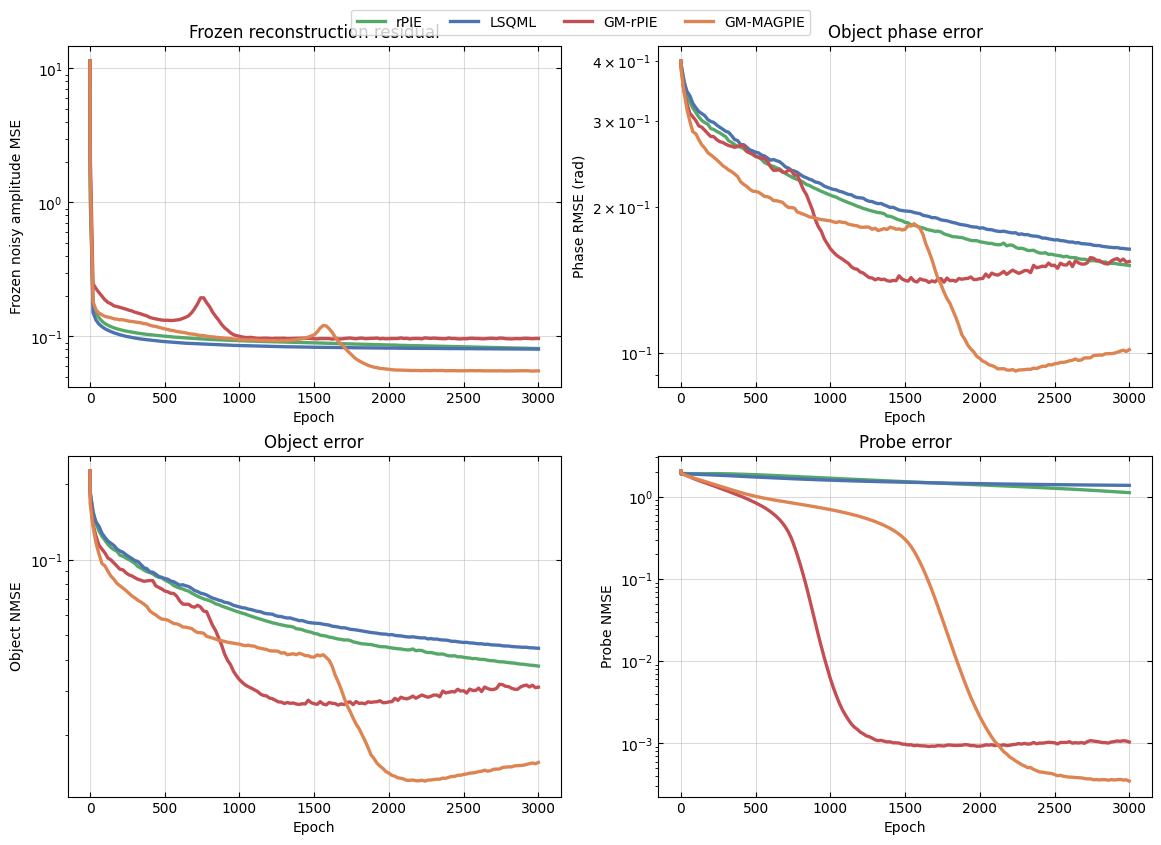

In [11]:
methods = completed_methods()
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.2), constrained_layout=True)
curve_specs = (
    (
        axes[0, 0],
        "Frozen reconstruction residual",
        "Frozen noisy amplitude MSE",
        FROZEN_NOISY_KEY,
    ),
    (axes[0, 1], "Object phase error", "Phase RMSE (rad)", "phase_rmse_rad"),
    (axes[1, 0], "Object error", "Object NMSE", "object_nmse"),
    (axes[1, 1], "Probe error", "Probe NMSE", "probe_nmse"),
)

for axis, title, ylabel, metric_name in curve_specs:
    for method_name in methods:
        result = results[method_name]
        values = result.metric_history[metric_name]
        valid = np.isfinite(values) & (values > 0)
        axis.semilogy(
            result.metric_epochs[valid],
            values[valid],
            linewidth=2.4,
            color=METHOD_COLORS[method_name],
            label=method_name,
        )
    axis.set(title=title, xlabel="Epoch", ylabel=ylabel)
    axis.grid(True, which="major", alpha=0.45)
    axis.grid(False, which="minor")
    axis.tick_params(direction="in", top=True, right=True)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(methods),
    bbox_to_anchor=(0.5, 1.02),
)
plt.show()

## Object comparison

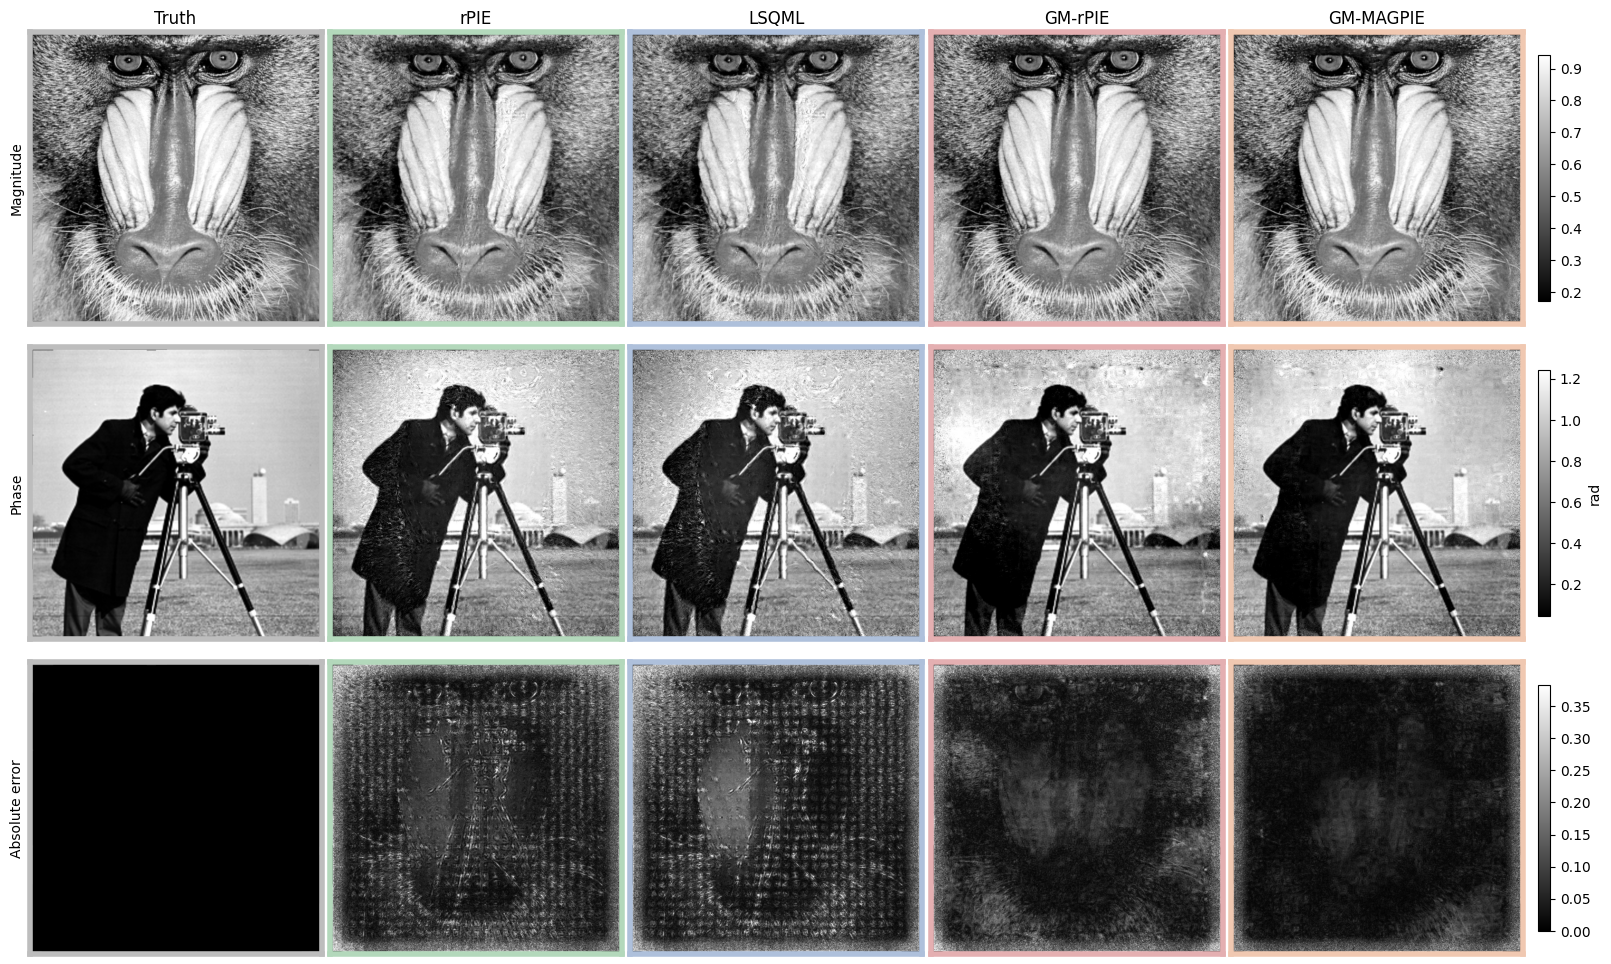

In [12]:
methods = [method for method in METHOD_ORDER if method in aligned_objects]
object_panels = {"Truth": registered_truth, **aligned_objects}
object_errors = {
    "Truth": np.zeros_like(np.abs(registered_truth), dtype=np.float32),
    **{
        method: np.abs(aligned_objects[method] - registered_truth)
        for method in methods
    },
}
magnitude_limits = robust_limits(
    np.abs(registered_truth[illuminated]),
    (1, 99),
    nonnegative=True,
)
phase_limits = robust_limits(np.angle(registered_truth[illuminated]), (1, 99))
error_max = robust_limits(
    np.concatenate([object_errors[method][illuminated] for method in methods]),
    (0, 99),
    nonnegative=True,
)[1]
object_cmap = plt.colormaps["gray"].copy()
object_cmap.set_bad("#202020")

fig, axes = plt.subplots(
    3,
    len(object_panels),
    figsize=(3.2 * len(object_panels), 9.6),
    constrained_layout=True,
    squeeze=False,
)
for column, (name, object_value) in enumerate(object_panels.items()):
    magnitude_image = axes[0, column].imshow(
        np.ma.array(np.abs(object_value), mask=~illuminated),
        cmap=object_cmap,
        vmin=magnitude_limits[0],
        vmax=magnitude_limits[1],
    )
    phase_image = axes[1, column].imshow(
        np.ma.array(np.angle(object_value), mask=~illuminated),
        cmap=object_cmap,
        vmin=phase_limits[0],
        vmax=phase_limits[1],
    )
    error_image = axes[2, column].imshow(
        np.ma.array(object_errors[name], mask=~illuminated),
        cmap=object_cmap,
        vmin=0.0,
        vmax=error_max,
    )
    axes[0, column].set_title(name)
    for row in range(3):
        axis = axes[row, column]
        axis.set(xticks=[], yticks=[])
        for spine in axis.spines.values():
            spine.set_color(PANEL_FRAME_COLORS[name])
            spine.set_linewidth(4.0)

axes[0, 0].set_ylabel("Magnitude")
axes[1, 0].set_ylabel("Phase")
axes[2, 0].set_ylabel("Absolute error")
fig.colorbar(magnitude_image, ax=axes[0, :], shrink=0.8, pad=0.01)
fig.colorbar(phase_image, ax=axes[1, :], shrink=0.8, pad=0.01, label="rad")
fig.colorbar(error_image, ax=axes[2, :], shrink=0.8, pad=0.01)
plt.show()

## Probe comparison

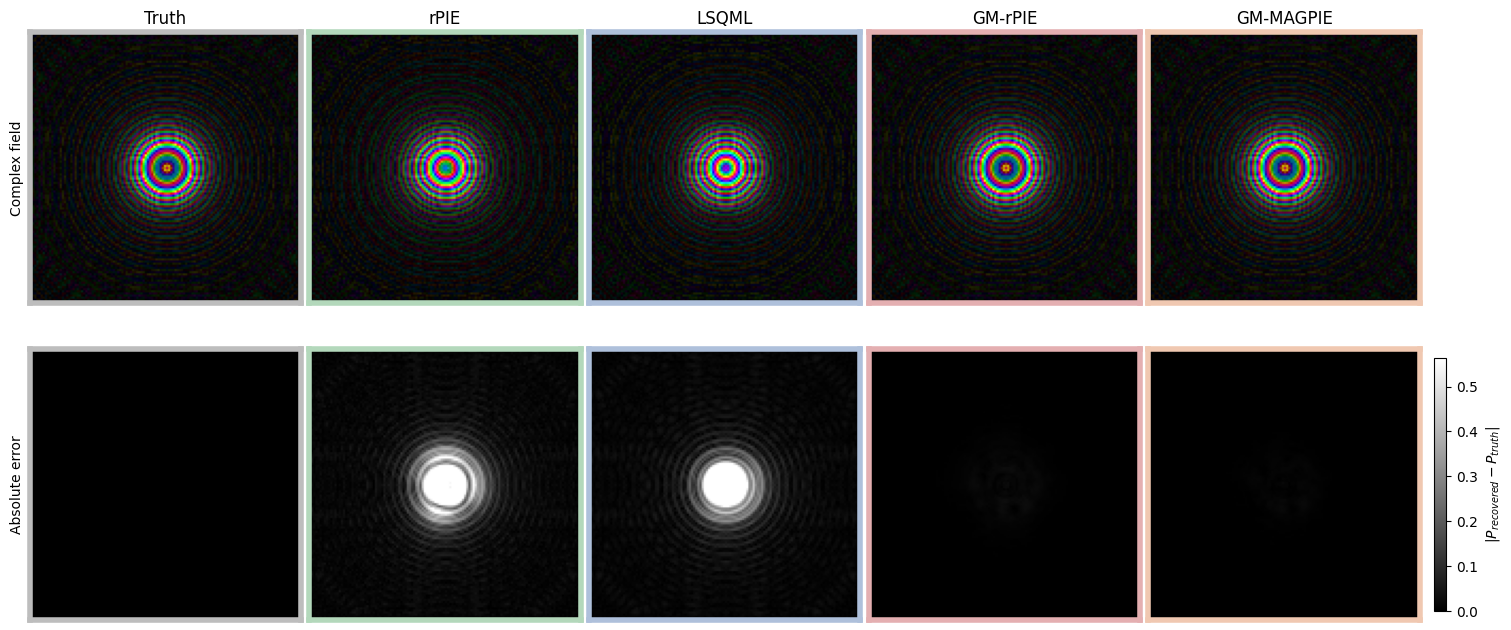

In [13]:
methods = [method for method in METHOD_ORDER if method in aligned_probes]
probe_panels = {"Truth": dataset.probe_truth, **aligned_probes}
probe_errors = {
    "Truth": np.zeros_like(np.abs(dataset.probe_truth), dtype=np.float32),
    **{
        method: np.abs(aligned_probes[method] - dataset.probe_truth)
        for method in methods
    },
}
magnitude_max = robust_limits(
    np.concatenate([np.abs(value).ravel() for value in probe_panels.values()]),
    (0, 99.8),
    nonnegative=True,
)[1]
error_max = robust_limits(
    np.concatenate([probe_errors[method].ravel() for method in methods]),
    (0, 99),
    nonnegative=True,
)[1]

fig, axes = plt.subplots(
    2,
    len(probe_panels),
    figsize=(3.0 * len(probe_panels), 6.4),
    constrained_layout=True,
    squeeze=False,
)
for column, (name, probe_value) in enumerate(probe_panels.items()):
    axes[0, column].imshow(complex_to_rgb(probe_value, magnitude_max))
    error_image = axes[1, column].imshow(
        probe_errors[name],
        cmap="gray",
        vmin=0.0,
        vmax=error_max,
    )
    axes[0, column].set_title(name)
    for row in range(2):
        axis = axes[row, column]
        axis.set(xticks=[], yticks=[])
        axis.set_facecolor("black")
        for spine in axis.spines.values():
            spine.set_color(PANEL_FRAME_COLORS[name])
            spine.set_linewidth(4.0)

axes[0, 0].set_ylabel("Complex field")
axes[1, 0].set_ylabel("Absolute error")
fig.colorbar(
    error_image,
    ax=axes[1, :],
    shrink=0.82,
    pad=0.01,
    label=r"$|P_{recovered} - P_{truth}|$",
)
plt.show()